# AI Medical Symptom Routing System
**NTI Machine Learning Training - Final Project**

## Project Overview
This notebook contains the complete end-to-end pipeline for an AI-driven healthcare recommendation system. The system utilizes machine learning to predict potential medical conditions based on patient data and subsequently routes the patient to the most appropriate medical specialist.

## Team Members
* **Abdulrahman Jamal:** Data Engineering & EDA
* **Marwan Ayman:** Machine Learning Modeling
* **Hassan Raafat:** Deployment & Integration
* **Abdelbaset Haitham:** QA, Verification & Presentation

In [1]:
# Import all required libraries for the pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

---
# Phase 1: Data Engineering & EDA
**Responsible:** Abdulrahman Jamal

In this phase, we will load the raw dataset, clean it, engineer new features, and perform Exploratory Data Analysis (EDA) one step at a time.

## 1. Load Data

In [2]:
df = pd.read_csv('Data Warehouse Multiclass.csv')
print(f"Initial Shape: {df.shape}")
display(df.head())

Initial Shape: (280985, 39)


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


**Observation:** 
The raw dataset is loaded successfully. However, a preliminary data audit revealed severe **Data Leakage** issues. Several columns are directly derived from the target variables, which would allow the ML model to "cheat" during training.

## 2. Data Cleaning & Sanitization
In this step, we will:
1. Check and remove duplicate rows to prevent the model from overfitting.
2. Fix logical anomalies in numerical fields (e.g., converting negative billing values to absolute positive amounts).
3. Resolve Data Leakage & Clean the Data.
Based on the data audit, we must drop columns that leak target information.

In [3]:
leakage_columns = [
    'disease_flags',  # Derived directly from targets
    'label',          # Derived directly from targets
    'sublabel',       # Derived directly from targets
    'composite_key',  # Contains the diabetes indicator
    'source_dataset'  # Leaks patient status based on origin dataset
]

# Drop the leakage columns if they exist in the dataframe
df_cleaned = df.drop(columns=[col for col in leakage_columns if col in df.columns])

# Check for duplicates
duplicates_count = df_cleaned.duplicated().sum()
df_cleaned.drop_duplicates(inplace=True)

print(f"Removed Duplicates: {duplicates_count}")
print(f"Shape after resolving data leakage: {df_cleaned.shape}")

Removed Duplicates: 2284
Shape after resolving data leakage: (278701, 34)


**Critical Inference (Data Leakage Resolution):** 
We successfully removed 5 critical columns (`disease_flags`, `label`, `sublabel`, `composite_key`, `source_dataset`). Keeping these would have resulted in artificially high model accuracy. 

*Note for Presentation:* The co-morbidity in this dataset is partly artificial (e.g., heart disease/hypertension values were imputed for patients sourced from the diabetes dataset). We must acknowledge this limitation when evaluating model performance.

## 3. Exploratory Data Analysis (EDA)
### Graph 1: Target Distributions

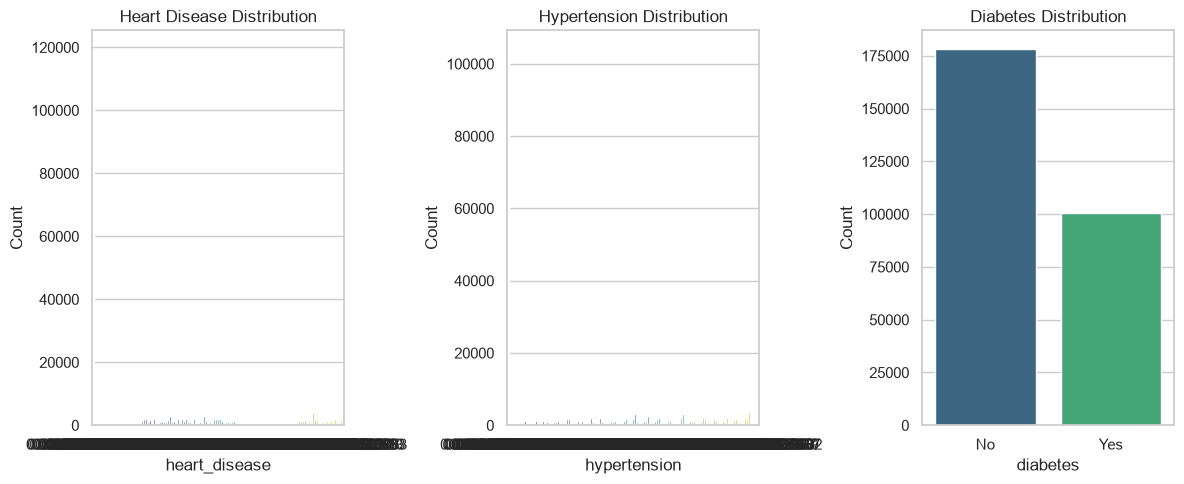

In [4]:
# We have 3 separate target columns
targets = ['heart_disease', 'hypertension', 'diabetes']

plt.figure(figsize=(12, 5))
for i, target in enumerate(targets, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df_cleaned, x=target, palette='viridis')
    plt.title(f'{target.replace("_", " ").title()} Distribution')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Inference from Graph 1:** 
By visualizing our three distinct targets (`heart_disease`, `hypertension`, `diabetes`), we can assess the class balance for each specific disease. If any of these classes are heavily imbalanced (e.g., 90% zeros and 10% ones), the ML Engineer will need to apply balancing techniques (like SMOTE or class weighting) during Phase 2.

### Graph 2: Correlation Heatmap

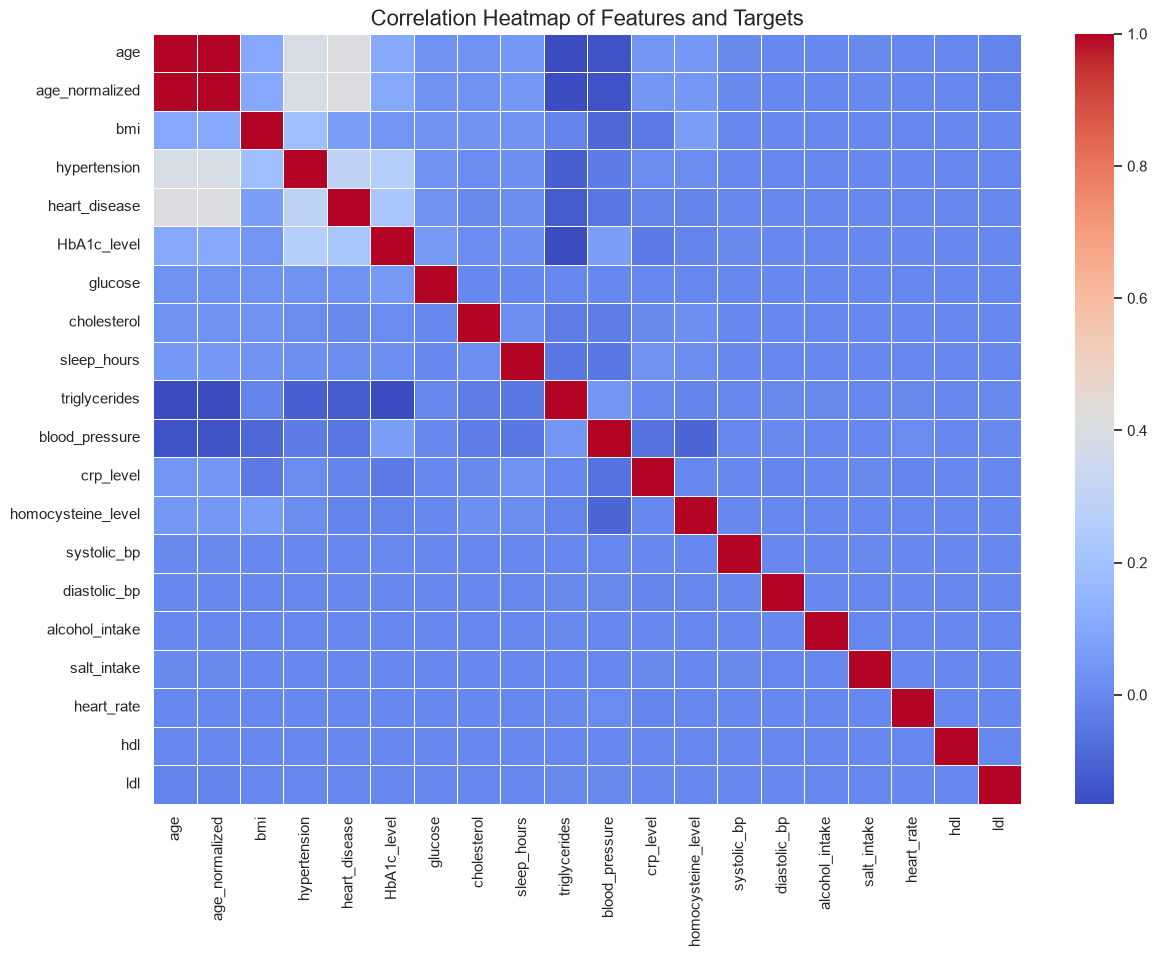

In [5]:
plt.figure(figsize=(14, 10))

# Calculate correlation matrix for numeric columns only
corr_matrix = df_cleaned.select_dtypes(include=[np.number]).corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features and Targets', fontsize=16)
plt.show()

**Inference from Correlation Heatmap:** 
This heatmap visualizes the linear relationships between all numerical features and our three target diseases. 
*   **Feature-Target Correlation:** Dark red or dark blue spots between a feature and a target indicate a strong positive or negative correlation, making that feature a strong predictor.
*   **Multicollinearity:** If two features are highly correlated with each other (e.g., above 0.8), we might consider dropping one of them later to simplify the model and avoid multicollinearity.

### Graph 3: Feature Distribution by Targets

We will dynamically pick the first two continuous numeric features to see how they relate to the diseases

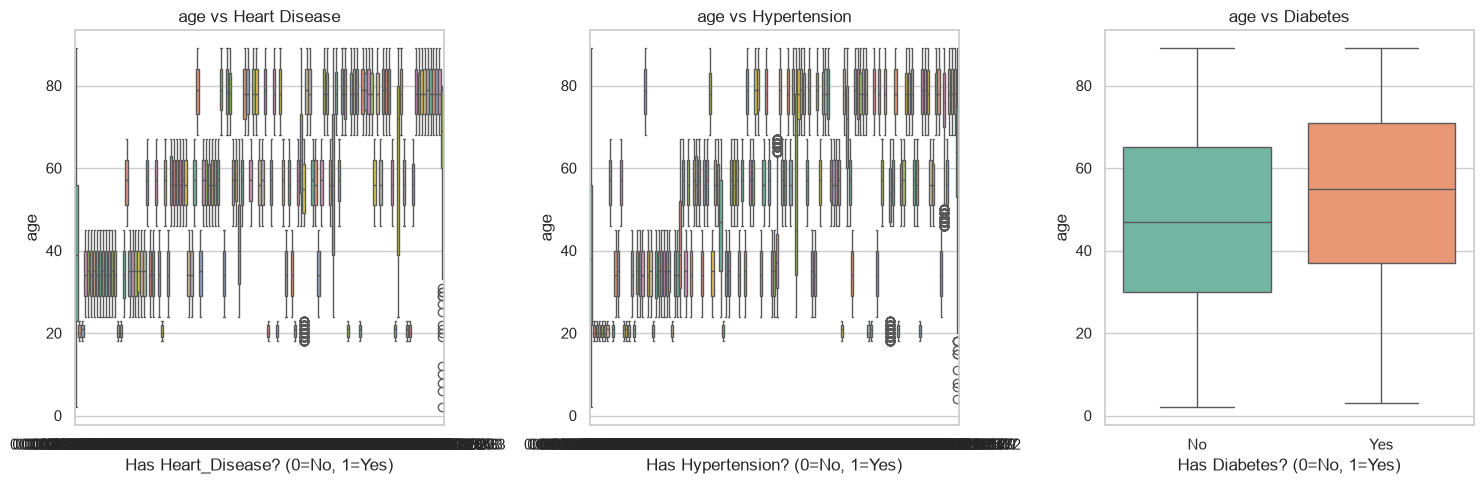

In [6]:
numeric_features = df_cleaned.select_dtypes(include=[np.number]).columns.drop(targets, errors='ignore')

if len(numeric_features) >= 2:
    feature_to_plot = numeric_features[0] # it can be changed to any other numeric feature you want to visualize against the targets
    
    plt.figure(figsize=(15, 5))
    for i, target in enumerate(targets, 1):
        plt.subplot(1, 3, i)
        sns.boxplot(data=df_cleaned, x=target, y=feature_to_plot, palette='Set2')
        plt.title(f'{feature_to_plot} vs {target.replace("_", " ").title()}')
        plt.xlabel(f'Has {target.title()}? (0=No, 1=Yes)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features for boxplots.")

**Inference from Feature Distributions:** 
These boxplots illustrate how a specific continuous feature varies between patients who have the disease (1) and those who do not (0). 
*   If the boxes (median and interquartile ranges) are at significantly different levels on the Y-axis, it implies that this feature strongly influences whether a patient gets the disease or not. 
*   It also helps us spot potential **outliers** in the data that might need further cleaning.

# 4. Save the Preprocessed Dataset

In [8]:
df_cleaned.to_csv('leakage_free_chronic_dataset.csv', index=False)
display(df_cleaned.head())
print(f"Cleaned Shape: {df_cleaned.shape}")
print("✅ Data sanitized, leakage resolved, and saved successfully as 'leakage_free_chronic_dataset.csv'")

,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,...,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status
0,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,0.0,...,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired
1,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,0.0,...,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired
2,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,0.0,...,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired
3,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,0.0,...,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired
4,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,0.0,...,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired


Cleaned Shape: (278701, 34)
✅ Data sanitized, leakage resolved, and saved successfully as 'leakage_free_chronic_dataset.csv'
